# 第 2 章　必備 Python 四大套件：NumPy、Pandas、Matplotlib、SciPy

本 notebook 對應「醫學生的機器學習入門」網站第 2 章：<https://med-study-rpg.com/ml/chapters/02-python-toolkit/>

**怎麼用：**

- 在 Google Colab 開啟後，從上到下按 `Shift + Enter` 逐格執行即可，不需要另外安裝任何套件。
- 需要網路：資料集會從 UCI Machine Learning Repository 直接下載（約 12 KB）。
- 圖上的標籤用英文，因為 Colab 預設沒有中文字型，中文會變成方塊。

**資料集：** Heart Failure Clinical Records（UCI 519，CC BY 4.0）。299 位心衰竭病人、12 個臨床變數與追蹤期間是否死亡（`death_event`）。
原始資料：Ahmad T et al. *PLoS One* 2017;12:e0181001；整理與分析：Chicco D, Jurman G. *BMC Med Inform Decis Mak* 2020;20:16；DOI 10.24432/C5Z89R。

> 本 notebook 的醫學內容僅供學習程式與統計概念，不構成臨床建議。

## 0. 確認套件版本

先印出版本，之後若結果和網站不一樣，可以先比對版本。

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats

print("Python    ", sys.version.split()[0])
print("NumPy     ", np.__version__)
print("pandas    ", pd.__version__)
print("Matplotlib", matplotlib.__version__)
print("SciPy     ", scipy.__version__)

Python     3.12.2
NumPy      2.1.3
pandas     2.2.3
Matplotlib 3.10.0
SciPy      1.16.3


## 1. NumPy：一次處理一整排數字

### 1.1 從 list 到陣列

先用 5 位病人的左心室射出分率（ejection fraction, EF，單位 %）示範。Python 內建的 list 不能直接做數學運算，NumPy 陣列（array）可以。

In [2]:
ef_list = [25, 38, 60, 20, 45]          # Python list
ef = np.array(ef_list)                   # NumPy array
print(ef, ef.dtype, ef.shape)
print(ef_list * 2)                       # list: repeats the list
print(ef * 2)                            # array: element-wise math

[25 38 60 20 45] int64 (5,)
[25, 38, 60, 20, 45, 25, 38, 60, 20, 45]
[ 50  76 120  40  90]


### 1.2 向量化：比較、篩選、統計量一行完成

`ef < 40` 會對每一個元素逐一比較，回傳一個 True/False 陣列（布林遮罩）；把遮罩放進中括號就能篩出符合的病人。

In [3]:
low = ef < 40                            # boolean mask
print(low)
print(ef[low])                           # patients with EF < 40%
print(low.sum(), "of", ef.size, "patients have EF < 40%")
print("mean =", ef.mean(), " SD (ddof=1) =", round(ef.std(ddof=1), 2))

[ True  True False  True False]
[25 38 20]
3 of 5 patients have EF < 40%
mean = 37.6  SD (ddof=1) = 16.01


### 1.3 為什麼要向量化：速度

同樣把 100 萬個數字平方後加總，比較 Python 迴圈和 NumPy 的時間（實際秒數依電腦而不同）。

In [4]:
import time

rng = np.random.default_rng(42)
x = rng.normal(size=1_000_000)
x_list = x.tolist()

t0 = time.perf_counter()
total = 0.0
for v in x_list:
    total += v * v
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
total_np = np.sum(x * x)
t_np = time.perf_counter() - t0

print(f"loop : {t_loop:.4f} s")
print(f"numpy: {t_np:.4f} s  (about {t_loop / t_np:.0f}x faster)")
print("same answer:", np.isclose(total, total_np))

loop : 0.0337 s
numpy: 0.0008 s  (about 43x faster)
same answer: True


### 1.4 二維陣列、`axis` 與廣播（broadcasting）

每一列（row）是一位病人，每一欄（column）是一項檢驗：血清肌酸酐（mg/dL）與血清鈉（mEq/L）。
`axis=0` 是「沿著列往下壓」，得到每一欄（每項檢驗）的統計量；`axis=1` 是「沿著欄往右壓」，得到每一列（每位病人）的統計量。

In [5]:
labs = np.array([
    [1.9, 130],
    [1.1, 137],
    [0.9, 140],
    [2.7, 134],
])                                       # rows = patients, cols = [creatinine, sodium]
print(labs.shape)
print("mean of each column (axis=0):", labs.mean(axis=0))
print("mean of each row    (axis=1):", labs.mean(axis=1))

(4, 2)
mean of each column (axis=0): [  1.65 135.25]
mean of each row    (axis=1): [65.95 69.05 70.45 68.35]


廣播：形狀 (4, 2) 的陣列減掉形狀 (2,) 的平均值，NumPy 會自動把平均值「複製」到每一列，不用寫迴圈。下面把每項檢驗轉成 z 分數（z-score），也順便示範單位換算（肌酸酐 mg/dL × 88.4 = µmol/L）。

In [6]:
mu = labs.mean(axis=0)                   # shape (2,)
sd = labs.std(axis=0, ddof=1)            # shape (2,)
z = (labs - mu) / sd                     # (4, 2) - (2,) -> broadcasting
print(np.round(z, 2))

creat_umol = labs[:, 0] * 88.4           # scalar broadcast to every patient
print(creat_umol)

[[ 0.3  -1.23]
 [-0.67  0.41]
 [-0.91  1.11]
 [ 1.28 -0.29]]
[167.96  97.24  79.56 238.68]


## 2. Pandas：有欄名的病歷總表

### 2.1 讀取資料

直接從 UCI 下載 zip，pandas 會自動解壓縮讀出裡面唯一的 CSV。若網路失敗，會嘗試用 `ucimlrepo`（Colab 需先 `%pip install -q ucimlrepo`），都失敗就顯示清楚的錯誤訊息。

In [7]:
URL = "https://archive.ics.uci.edu/static/public/519/heart+failure+clinical+records.zip"

def load_heart_failure():
    try:
        return pd.read_csv(URL)
    except Exception as e_url:
        try:
            from ucimlrepo import fetch_ucirepo
            r = fetch_ucirepo(id=519)
            return r.data.features.join(r.data.targets)
        except Exception as e_uci:
            raise RuntimeError(
                "Download failed. Check your internet connection, "
                "or download the zip manually from "
                "https://archive.ics.uci.edu/dataset/519 and use pd.read_csv('<file>.csv'). "
                f"URL error: {e_url!r}; ucimlrepo error: {e_uci!r}"
            ) from e_uci

df = load_heart_failure()
df = df.rename(columns={"DEATH_EVENT": "death_event"})
print(df.shape)
df.head()

(299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


### 2.2 先看全貌：`info()` 與 `describe()`

`info()` 告訴你每欄的型別與非空值數量（這份資料沒有遺漏值）；`describe()` 一次算出平均、標準差、四分位數。

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  death_event               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [9]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.83,11.89,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.43,0.50,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.84,970.29,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.08,11.83,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.35,0.48,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.03,97804.24,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.39,1.03,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.63,4.41,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.65,0.48,0.0,0.0,1.0,1.0,1.0


### 2.3 選欄與篩選列

- 選欄：`df["age"]` 得到一個 Series；`df[["age", "sex"]]` 得到 DataFrame。
- 篩選列：用布林條件，多個條件用 `&`（且）、`|`（或），每個條件要加括號。
- 同時選列與欄：`df.loc[列條件, 欄名]`。

In [10]:
cols = ["age", "ejection_fraction", "serum_creatinine", "death_event"]
severe = df.loc[(df["ejection_fraction"] < 30) & (df["age"] >= 70), cols]
print(len(severe), "patients: EF < 30% and age >= 70")
severe.head()

13 patients: EF < 30% and age >= 70


,age,ejection_fraction,serum_creatinine,death_event
0,75.0,20,1.90,1
6,75.0,15,1.20,1
18,70.0,25,1.00,1
40,70.0,20,1.83,1
48,80.0,20,4.40,1


### 2.4 新增欄位（一律用 `df["新欄"] = ...` 或 `.loc`）

用 `pd.cut` 把 EF 分成三組（此切點只是教學示範，實際分類請依最新指引）。

In [11]:
df["ef_group"] = pd.cut(
    df["ejection_fraction"],
    bins=[0, 40, 49, 100],
    labels=["EF<=40", "EF41-49", "EF>=50"],
)
df["creatinine_umol"] = df["serum_creatinine"] * 88.4
df["ef_group"].value_counts().sort_index()

ef_group
EF<=40     219
EF41-49     20
EF>=50      60
Name: count, dtype: int64

### 2.5 分組彙整：`groupby`

「死亡組與存活組各自的平均值」是臨床論文 Table 1 最常見的問題。`groupby` 一行做到。

In [12]:
num_cols = ["age", "ejection_fraction", "serum_creatinine", "serum_sodium"]
df.groupby("death_event")[num_cols].agg(["mean", "std"]).round(2)

age        ejection_fraction        serum_creatinine        \
              mean    std              mean    std             mean   std   
death_event                                                                 
0            58.76  10.64             40.27  10.86             1.18  0.65   
1            65.22  13.21             33.47  12.53             1.84  1.47   

            serum_sodium        
                    mean   std  
death_event                     
0                 137.22  3.98  
1                 135.38  5.00

各 EF 分組的死亡比例（`death_event` 是 0/1，所以平均值就是比例）。`ef_group` 是類別型欄位，`observed=True` 表示只列出實際出現的組別。

In [13]:
df.groupby("ef_group", observed=True)["death_event"].agg(["count", "mean"]).round(3)

,count,mean
ef_group,,
EF<=40,219,0.352
EF41-49,20,0.250
EF>=50,60,0.233


### 2.6 列聯表：`pd.crosstab`

兩個類別變數交叉計數，下一節的卡方檢定就是吃這張表。

In [14]:
tab = pd.crosstab(df["high_blood_pressure"], df["death_event"])
print(tab)
print(pd.crosstab(df["high_blood_pressure"], df["death_event"], normalize="index").round(3))

death_event            0   1
high_blood_pressure         
0                    137  57
1                     66  39
death_event              0      1
high_blood_pressure              
0                    0.706  0.294
1                    0.629  0.371


## 3. Matplotlib：一張圖看分布

本章只用一種寫法：`fig, ax = plt.subplots()`，每張子圖（`ax`）都要有標題、軸標籤，有兩組以上就加圖例。

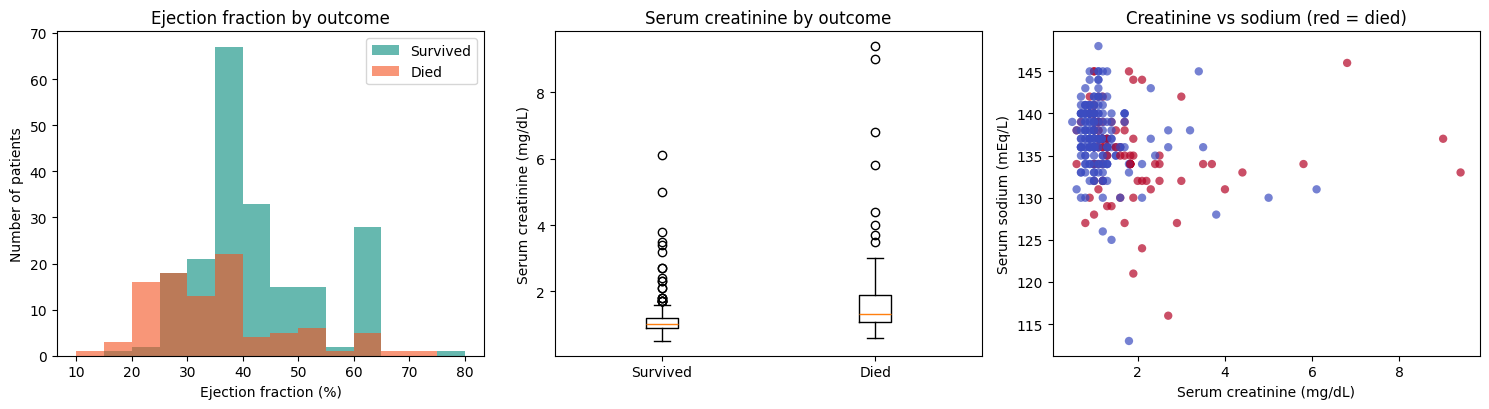

In [15]:
dead = df[df["death_event"] == 1]
alive = df[df["death_event"] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) histogram
bins = np.arange(10, 85, 5)
axes[0].hist(alive["ejection_fraction"], bins=bins, alpha=0.6, label="Survived", color="#00897B")
axes[0].hist(dead["ejection_fraction"], bins=bins, alpha=0.6, label="Died", color="#F4511E")
axes[0].set_title("Ejection fraction by outcome")
axes[0].set_xlabel("Ejection fraction (%)")
axes[0].set_ylabel("Number of patients")
axes[0].legend()

# (b) box plot
axes[1].boxplot([alive["serum_creatinine"], dead["serum_creatinine"]],
                tick_labels=["Survived", "Died"])
axes[1].set_title("Serum creatinine by outcome")
axes[1].set_ylabel("Serum creatinine (mg/dL)")

# (c) scatter plot
axes[2].scatter(df["serum_creatinine"], df["serum_sodium"], c=df["death_event"],
                cmap="coolwarm", alpha=0.7, edgecolors="none")
axes[2].set_title("Creatinine vs sodium (red = died)")
axes[2].set_xlabel("Serum creatinine (mg/dL)")
axes[2].set_ylabel("Serum sodium (mEq/L)")

fig.tight_layout()
plt.show()

讀圖重點：(a) 死亡組的 EF 分布偏左；(b) 肌酸酐是右偏分布，有不少離群值；(c) 兩個檢驗值之間只有微弱的負向趨勢，右側少數極端值很顯眼。

## 4. SciPy：用 `scipy.stats` 做常見檢定

提醒：以下都是**來自巴基斯坦 Faisalabad 兩家醫院、299 人的觀察性資料**，檢定結果只描述「組間是否有統計上可偵測的差異或關聯」，不代表因果，也沒有校正干擾因子或多重比較。

### 4.1 兩組平均值：Welch t 檢定

比較死亡組與存活組的 EF。`equal_var=False` 是 Welch t 檢定，不假設兩組變異數相同，實務上較穩健。除了 p 值，也印出平均差與 95% 信賴區間（效果大小）。

In [16]:
res = stats.ttest_ind(dead["ejection_fraction"], alive["ejection_fraction"], equal_var=False)
diff = dead["ejection_fraction"].mean() - alive["ejection_fraction"].mean()
ci = res.confidence_interval(confidence_level=0.95)
print(f"mean EF: died {dead['ejection_fraction'].mean():.1f}%, survived {alive['ejection_fraction'].mean():.1f}%")
print(f"difference = {diff:.1f} percentage points, 95% CI {ci.low:.1f} to {ci.high:.1f}")
print(f"t = {res.statistic:.2f}, p = {res.pvalue:.2g}")

mean EF: died 33.5%, survived 40.3%
difference = -6.8 percentage points, 95% CI -9.7 to -3.9
t = -4.57, p = 9.6e-06


### 4.2 偏態資料：Mann-Whitney U 檢定

肌酸酐明顯右偏（盒鬚圖有很多離群值），比較兩組時常改用不假設常態的 Mann-Whitney U 檢定，並用中位數描述。

In [17]:
print("median creatinine: died", dead["serum_creatinine"].median(),
      "| survived", alive["serum_creatinine"].median())
mw = stats.mannwhitneyu(dead["serum_creatinine"], alive["serum_creatinine"])
print(f"Mann-Whitney U = {mw.statistic:.0f}, p = {mw.pvalue:.2g}")

median creatinine: died 1.3 | survived 1.0
Mann-Whitney U = 14190, p = 1.6e-10


### 4.3 兩個類別變數：卡方檢定 `chi2_contingency`

用 2.6 的列聯表檢定「高血壓」與「死亡」是否有關聯。注意結果**未達統計顯著**時的寫法。

In [18]:
chi2 = stats.chi2_contingency(tab)
print(f"chi2 = {chi2.statistic:.2f}, dof = {chi2.dof}, p = {chi2.pvalue:.3f}")
print("expected counts:")
print(np.round(chi2.expected_freq, 1))
rate = tab[1] / tab.sum(axis=1)
print("death rate: HTN =", round(rate[1], 3), "| no HTN =", round(rate[0], 3))

chi2 = 1.54, dof = 1, p = 0.214
expected counts:
[[131.7  62.3]
 [ 71.3  33.7]]
death rate: HTN = 0.371 | no HTN = 0.294


### 4.4 兩個連續變數：Pearson 與 Spearman 相關

Pearson 相關係數 r 衡量線性關係，容易被離群值牽動；Spearman 用排名計算，對離群值較不敏感。

In [19]:
pr = stats.pearsonr(df["serum_creatinine"], df["serum_sodium"])
pci = pr.confidence_interval(confidence_level=0.95)
sr = stats.spearmanr(df["serum_creatinine"], df["serum_sodium"])
print(f"Pearson  r   = {pr.statistic:.3f} (95% CI {pci.low:.3f} to {pci.high:.3f}), p = {pr.pvalue:.2g}")
print(f"Spearman rho = {sr.statistic:.3f}, p = {sr.pvalue:.2g}")

Pearson  r   = -0.189 (95% CI -0.296 to -0.077), p = 0.001
Spearman rho = -0.300, p = 1.2e-07


## 5. 動手試試

1. **改切點**：把 2.4 的 `bins` 改成 `[0, 30, 45, 100]`，重跑 2.5 的分組死亡比例，觀察比例怎麼變。
2. **換變數做 t 檢定**：把 4.1 的 `ejection_fraction` 換成 `platelets`（血小板），看看 p 值與信賴區間，並用「未達統計顯著」的正確措辭寫一句結論。
3. **看離群值的影響**：在 4.4 前先用 `sub = df[df["serum_creatinine"] < 3]` 排除肌酸酐 ≥ 3 mg/dL 的人，再算一次 Pearson r，和原本的結果比較。

In [20]:
# Exercise space: try your code here